# Regression

- Author: Arnold Atchoe.
- Date: 2026-07
- Dataset: Seaborn Penguins
- Target: bill_depth_mm(We want to determine the lenght of a penguin's beak affects its depth)

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M4. Regression

This notebook fits a line and computes the numbers analysts use to judge a fit:

- R-squared
- RMSE
- residuals
  
It shows how complexity changes train vs. test errors. 

The analyst decides whether the fit is "good" and 
how much complexity is right. 
Code calculates values, but the analyst decides.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

## Overview

This project uses the penguins dataset.
We choose to predict the target `bill_depth_mm`.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. When to Use Regression, and How We Judge It

Use **regression** when the target is a **number** - mass, price, temperature,
demand. (A category target is classification, Module 3.)

We judge a regression on held-out data, with:

- **R-squared** - the fraction of the variation in the target the model explains
  (roughly 0 to 1; higher is more).
- **RMSE** - root mean squared error, the typical size of a miss, in the target's units.
- **residual plot** - actual minus predicted. If a straight line fits well, residuals
  scatter randomly around zero with no pattern. A curve or a funnel says the line is
  the wrong shape - itself a useful finding.

**Over- vs. under-fitting:** a model too simple **underfits** (misses real structure;
poor on both train and test). A model too complex **overfits** (memorizes the training
data; great on train, worse on test). You detect it by comparing train and test error
as complexity changes - Section 6.

## Section 1. Project Setup and Imports

In [20]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M04", level="DEBUG")
log_header(LOG, "M04")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-26 14:41:01 | INFO | M04 | === RUN START ===
2026-07-26 14:41:01 | INFO | M04 | project=M04
2026-07-26 14:41:01 | INFO | M04 | repo_dir=ml-04-regression
2026-07-26 14:41:01 | INFO | M04 | python=3.14.6
2026-07-26 14:41:01 | INFO | M04 | os=Windows 11
2026-07-26 14:41:01 | INFO | M04 | shell=powershell
2026-07-26 14:41:01 | INFO | M04 | cwd=notebooks
2026-07-26 14:41:01 | INFO | M04 | github_actions=False
2026-07-26 14:41:01 | INFO | M04 | Confirming installation:
2026-07-26 14:41:01 | INFO | M04 |   python:       3.14.6
2026-07-26 14:41:01 | INFO | M04 |   pandas:       3.0.5
2026-07-26 14:41:01 | INFO | M04 |   numpy:        2.5.1
2026-07-26 14:41:01 | INFO | M04 |   scikit-learn: 1.9.0
2026-07-26 14:41:01 | INFO | M04 |   seaborn:      0.13.2
2026-07-26 14:41:01 | INFO | M04 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [21]:
# === Section 2. Load and Prepare the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")


# CUSTOM: ANALYST CHOICE - one numeric feature (x) and one numeric target (y).
# This pairing is expected to be close to a straight line; we still fit and look.
FEATURE_COL: Final[str] = "bill_length_mm"
TARGET_COL: Final[str] = "bill_depth_mm"

FEATURE_LABEL: Final[str] = "Bill length (mm)"
TARGET_LABEL: Final[str] = "Bill depth (mm)"

df_model: pd.DataFrame = df.dropna(subset=[FEATURE_COL, TARGET_COL]).copy()
LOG.info(f"Original rows: {df.shape[0]}  Model rows: {df_model.shape[0]}")

# Drop columns that are not needed for the model.
df_model.drop(
    columns=[col for col in df_model.columns if col not in [FEATURE_COL, TARGET_COL]],
    inplace=True,
)

# Inspect model data for missing values, outliers, and basic statistics.
LOG.info(f"Missing values:\n{df_model.isna().sum()}")
LOG.info(f"Basic statistics:\n{df_model.describe()}")
LOG.info("Outliers (using IQR method):")
Q1: float = df_model[FEATURE_COL].quantile(0.25)
Q3: float = df_model[FEATURE_COL].quantile(0.75)
IQR: float = Q3 - Q1
outliers: pd.DataFrame = df_model[
    (df_model[FEATURE_COL] < Q1 - 1.5 * IQR) | (df_model[FEATURE_COL] > Q3 + 1.5 * IQR)
]
LOG.info(f"{outliers.shape[0]} outliers found:\n{outliers}")

2026-07-26 14:41:01 | INFO | M04 | Loading dataset: penguins
2026-07-26 14:41:01 | INFO | M04 | Loaded: 344 rows (instances), 7 columns
2026-07-26 14:41:01 | INFO | M04 | Original rows: 344  Model rows: 342
2026-07-26 14:41:01 | INFO | M04 | Missing values:
bill_length_mm    0
bill_depth_mm     0
dtype: int64
2026-07-26 14:41:01 | INFO | M04 | Basic statistics:
       bill_length_mm  bill_depth_mm
count      342.000000     342.000000
mean        43.921930      17.151170
std          5.459584       1.974793
min         32.100000      13.100000
25%         39.225000      15.600000
50%         44.450000      17.300000
75%         48.500000      18.700000
max         59.600000      21.500000
2026-07-26 14:41:01 | INFO | M04 | Outliers (using IQR method):
2026-07-26 14:41:01 | INFO | M04 | 0 outliers found:
Empty DataFrame
Columns: [bill_length_mm, bill_depth_mm]
Index: []


## Section 3. Split into Train and Test


ANALYST CHOICE

We hold out a test set the model never sees
so R-squared and RMSE reflect new data. 

Without a held-out set we cannot tell a good fit from memorization.

In [22]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X (2-D) and y (1-D), then split into train and test.

WHY: scikit-learn wants X as shape (n, 1) and y as shape (n,).

Double brackets give a DataFrame (2-D);
single brackets give a Series (1-D).
"""

# Declare X to hold the feature values,
# which will be used for model fitting.
X: np.ndarray = df_model[[FEATURE_COL]].to_numpy()

# Declare y to hold the target values,
# which will be used for model fitting.
y: np.ndarray = df_model[TARGET_COL].to_numpy()

# Declare X_train to hold the training feature values,
# which will be used for model fitting.
X_train: np.ndarray

# Declare X_test to hold the test feature values,
# which will be used for evaluation after model training.
X_test: np.ndarray

# Declare y_train to hold the training target values,
# which will be used for model fitting.
y_train: np.ndarray

# Declare y_test to hold the test target values,
# which will be used for evaluation after model training.
y_test: np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-26 14:41:01 | INFO | M04 | Train instances: 273
2026-07-26 14:41:01 | INFO | M04 | Test instances: 69


## Section 4. Fit a Straight Line

In [23]:
# === Section 4. Fit a Straight Line ===


"""
Fit y = slope * x + intercept with scikit-learn.

WHY: create -> .fit() -> read results / .predict()
 is the same pattern for every scikit-learn model.

The model exposes .coef_ (slope) and .intercept_.
"""

LOG.info("Fitting a linear regression (scikit-learn)")

# create a linear regression model object (untrained)
model = LinearRegression()

# fit the model to the training data (learn the slope and intercept)
model.fit(X_train, y_train)

# retrieve the results (slope and intercept) and log them

slope: float = float(model.coef_[0])
intercept: float = float(model.intercept_)

LOG.info(f"Fitted line: {TARGET_COL} = {slope:.6g} * {FEATURE_COL} + {intercept:.6g}")

2026-07-26 14:41:01 | INFO | M04 | Fitting a linear regression (scikit-learn)
2026-07-26 14:41:01 | INFO | M04 | Fitted line: bill_depth_mm = -0.0798117 * bill_length_mm + 20.6196


## Section 5. Evaluate the Model Fit

2026-07-26 14:41:01 | INFO | M04 | Fit numbers on the TEST set (for you to interpret):
2026-07-26 14:41:01 | INFO | M04 |   R-squared: 0.0648
2026-07-26 14:41:01 | INFO | M04 |   RMSE:      1.86874  (in units of Bill depth (mm))


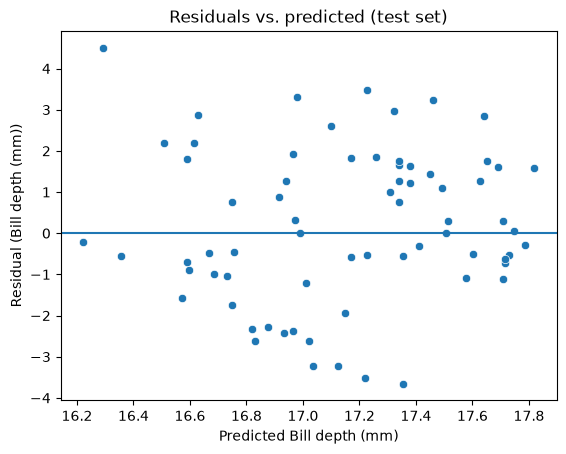

In [24]:
# === Section 5. Evaluate the Model Fit ===

# With regression, we use  R-squared, RMSE, and Residuals

"""
Report test R-squared and RMSE, and show a residual plot.

WHY: These are how the analyst decides
whether the line is a fair description.

This reports them on held-out data;
it does NOT declare the fit good or bad.

The analyst uses the numbers and the residual plot to decide.
"""

y_hat: np.ndarray = model.predict(X_test)

# Use float() to convert from numpy types to native Python types
residuals: np.ndarray = y_test - y_hat
r_squared: float = float(model.score(X_test, y_test))
rmse: float = float(np.sqrt(np.mean(residuals**2)))

LOG.info("Fit numbers on the TEST set (for you to interpret):")
LOG.info(f"  R-squared: {r_squared:.4f}")
LOG.info(f"  RMSE:      {rmse:.6g}  (in units of {TARGET_LABEL})")

# Residual plot: random scatter around 0 means a straight line fits well.

# Start a new figure
plt.figure()

# Create a scatter plot of residuals vs. predicted values
sns.scatterplot(x=y_hat, y=residuals)

# Add a horizontal line at y=0 to help visualize the residuals
plt.axhline(0)

# Label the axes and add a title
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title("Residuals vs. predicted (test set)")

# show the plot
plt.show()

### Interpretation

The residuals are pretty random about 0, with no obvious curve or funnel, 
so it looks like a straight line (degree=1) provides a good model. 

## Section 6. Detect Over- and Under-Fitting

Fit polynomials of increasing **degree** 
(degree 1 is the straight line) and plot
train vs. test RMSE. 

Underfitting shows as both errors high; 
overfitting shows as train RMSE falling while test RMSE rises. 

The best degree is where **test error is lowest** 
and the train/test gap is small.

The analyst decides which degree that is.

2026-07-26 14:41:01 | DEBUG | M04 |   degree= 1  train RMSE=1.92929  test RMSE=1.86874
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 1  RMSE difference=0.0605459
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 2  train RMSE=1.85826  test RMSE=1.85555
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 2  RMSE difference=0.00271318
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 3  train RMSE=1.83029  test RMSE=1.81396
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 3  RMSE difference=0.0163208
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 4  train RMSE=1.68048  test RMSE=1.84589
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 4  RMSE difference=0.165408
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 5  train RMSE=1.66088  test RMSE=1.84075
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 5  RMSE difference=0.179861
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 6  train RMSE=1.62936  test RMSE=1.81847
2026-07-26 14:41:01 | DEBUG | M04 |   degree= 6  RMSE difference=0.189107
2026-07-26 14:41:01 | DEBUG | 

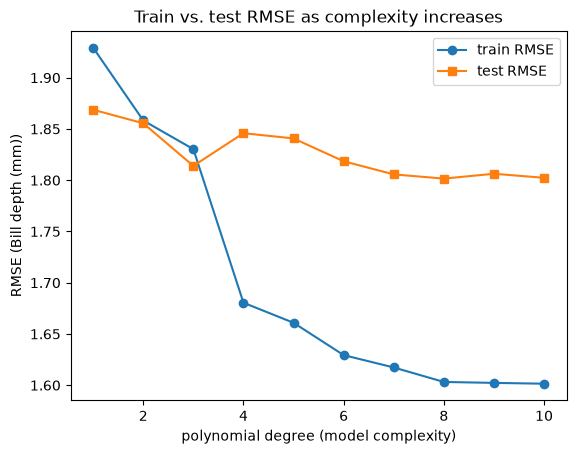

In [25]:
# === Section 6. Detect Over- and Under-Fitting ===

"""Show train vs. test RMSE as polynomial degree increases.

WHY: Error is not a fixed property of "the model"; it moves with complexity.
Watching train and test diverge is how you detect over- and under-fitting and
pick complexity on purpose. numpy fits the polynomial; nothing hidden.
"""

# Call .ravel() to convert from
# shape (n, 1) to shape (n,) for np.polyfit and np.polyval.
x_train: np.ndarray = X_train.ravel()
x_test: np.ndarray = X_test.ravel()

# CUSTOM: ANALYST CHOICE
# for penguins, sweep from 1 to 10 as a good range.
# THIS IS DATA SET DEPENDENT and ANALYST CHOICE.

MAX_SWEEP: Final[int] = 10

# Declare lists to hold the degrees and corresponding train/test RMSE.
degrees: list[int] = list(range(1, MAX_SWEEP + 1))
train_rmse: list[float] = []
test_rmse: list[float] = []

for degree in degrees:
    # Calculate the coefficients of the polynomial fit for the given degree
    coeffs: np.ndarray = np.polyfit(x_train, y_train, degree)

    # Calculate the predicted values for the training and test sets using the polynomial coefficients
    train_pred: np.ndarray = np.polyval(coeffs, x_train)
    test_pred: np.ndarray = np.polyval(coeffs, x_test)

    # Calculate and store the RMSE for the training and test sets
    train_rmse.append(float(np.sqrt(np.mean((y_train - train_pred) ** 2))))
    test_rmse.append(float(np.sqrt(np.mean((y_test - test_pred) ** 2))))
    LOG.debug(
        f"  degree={degree:2d}  train RMSE={train_rmse[-1]:.6g}  test RMSE={test_rmse[-1]:.6g}"
    )

    # Calculate difference between train and test RMSE for each degree
    rmse_diff: float = abs(train_rmse[-1] - test_rmse[-1])
    LOG.debug(f"  degree={degree:2d}  RMSE difference={rmse_diff:.6g}")

# start a new figure
plt.figure()

# Plot the train and test RMSE against the polynomial degree
# to visualize overfitting and underfitting.
plt.plot(degrees, train_rmse, marker="o", label="train RMSE")
plt.plot(degrees, test_rmse, marker="s", label="test RMSE")

# Label the axes and add a title
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel(f"RMSE ({TARGET_LABEL})")
plt.title("Train vs. test RMSE as complexity increases")

# Add a legend
plt.legend()

# Show the plot
plt.show()

### Interpretation
Considering the range of the bill_depth_mm values, errors greater than 1 mm seem significant. At degree 1, the RMSE for both the training and test data is relatively high, suggesting that the model may be underfitting. At degree 2, the RMSE for both the training and test sets begins to decrease, and the difference between the two is the smallest at this point, indicating a good fit. This trend continues at degree 3, suggesting that at this level of complexity the model provides a good balance between fitting the training data and generalizing to the test data.

After degree 3, the RMSE for the training set continues to decrease while the RMSE for the test set begins to increase, indicating that the model is starting to overfit. From degree 6 onward, the RMSE for both the training and test sets decreases again. However, there is still a large gap between the training and test RMSE, which is another indication that the model is overfitting despite the lower test error. The increase in the test RMSE at degree 9, while the training RMSE continues to decrease, further supports this conclusion, as it shows that the model is fitting the training data better without improving its performance on unseen data.

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [26]:
# === Python Summary ===


"""Record what was fit and the judgment still owed."""
slope: float = float(model.coef_[0])
intercept: float = float(model.intercept_)
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:  {DATASET_NAME}")
LOG.info(f"Feature:  {FEATURE_COL}  ->  Target: {TARGET_COL}  (regression)")
LOG.info(f"Line:     {TARGET_COL} = {slope:.6g} * {FEATURE_COL} + {intercept:.6g}")
LOG.info("========================")

2026-07-26 14:41:02 | INFO | M04 | ========================
2026-07-26 14:41:02 | INFO | M04 | SUMMARY
2026-07-26 14:41:02 | INFO | M04 | ========================
2026-07-26 14:41:02 | INFO | M04 | Dataset:  penguins
2026-07-26 14:41:02 | INFO | M04 | Feature:  bill_length_mm  ->  Target: bill_depth_mm  (regression)
2026-07-26 14:41:02 | INFO | M04 | Line:     bill_depth_mm = -0.0798117 * bill_length_mm + 20.6196
2026-07-26 14:41:02 | INFO | M04 | ========================



### Summary

For this technical modification:
- `Bill_depth_mm` was the target variable.
- `Bill_length_mm` was the feature variable.
- I loaded the penguins dataset.
- Checked columns for missing values, duplicates and outliers.
- Dropped 2 rows because of duplication 
- Dropped all columns except `Bill_depth_mm` and  `Bill_length_mm`
- Explored the numerical statitics of  `Bill_depth_mm` and  `Bill_length_mm`
- Since data had no errors, I proceeded to split into train set and test.
- Train set was used to generate regression equation represent the line of best fit(Fitted line: bill_depth_mm = -0.0798117 * bill_length_mm + 20.6196) with the following evaluaion metrics 
  *  R-squared: 0.0648 (Model accounts for or explains only 6.48% of the change in bill_depth_mm)
  *  RMSE: 1.86874  (in units of Bill depth (mm))
- Compared the RMSE for train set and test set at varying degrees of complexity to determine degrees at which overfitting and underfitting occurs. The interpretation section details this.
- From my analysis the model at complexity 2 is best fit.
